In [1]:
import sys
print(sys.executable)


In [7]:
!mamba install pandas openpyxl matplotlib 

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, openpyxl
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.8319000000357628 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ et_xmlfile                    2.0.0                         pyhd8ed1ab_1                  conda-forge                   
+ openpyxl                      3.0.9                         pyhd8ed1ab_0                  conda-forge                   
+ pandas                        3.0.0                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3     

Distribution of Dominant MI Types:
Dominant_MI
Intrapersonal    50
Interpersonal    35
Musical          27
Kinesthetic      24
Logical          21
Verbal           19
Existential      18
Naturalist       14
Visual            6
Name: count, dtype: int64



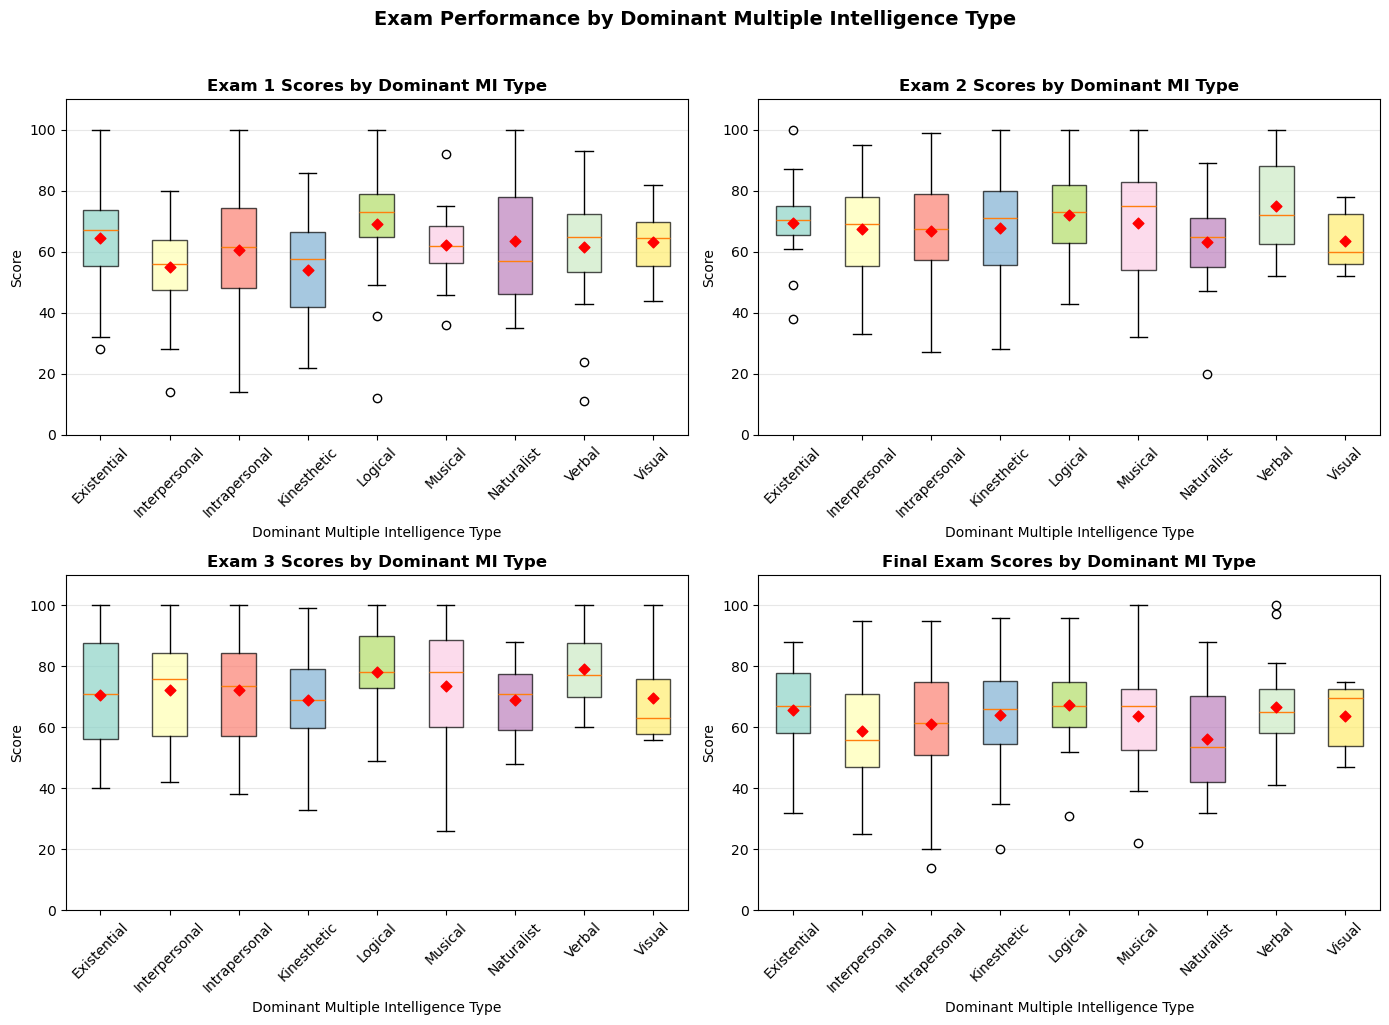

Plot 1 saved: mi_exam_boxplots.png


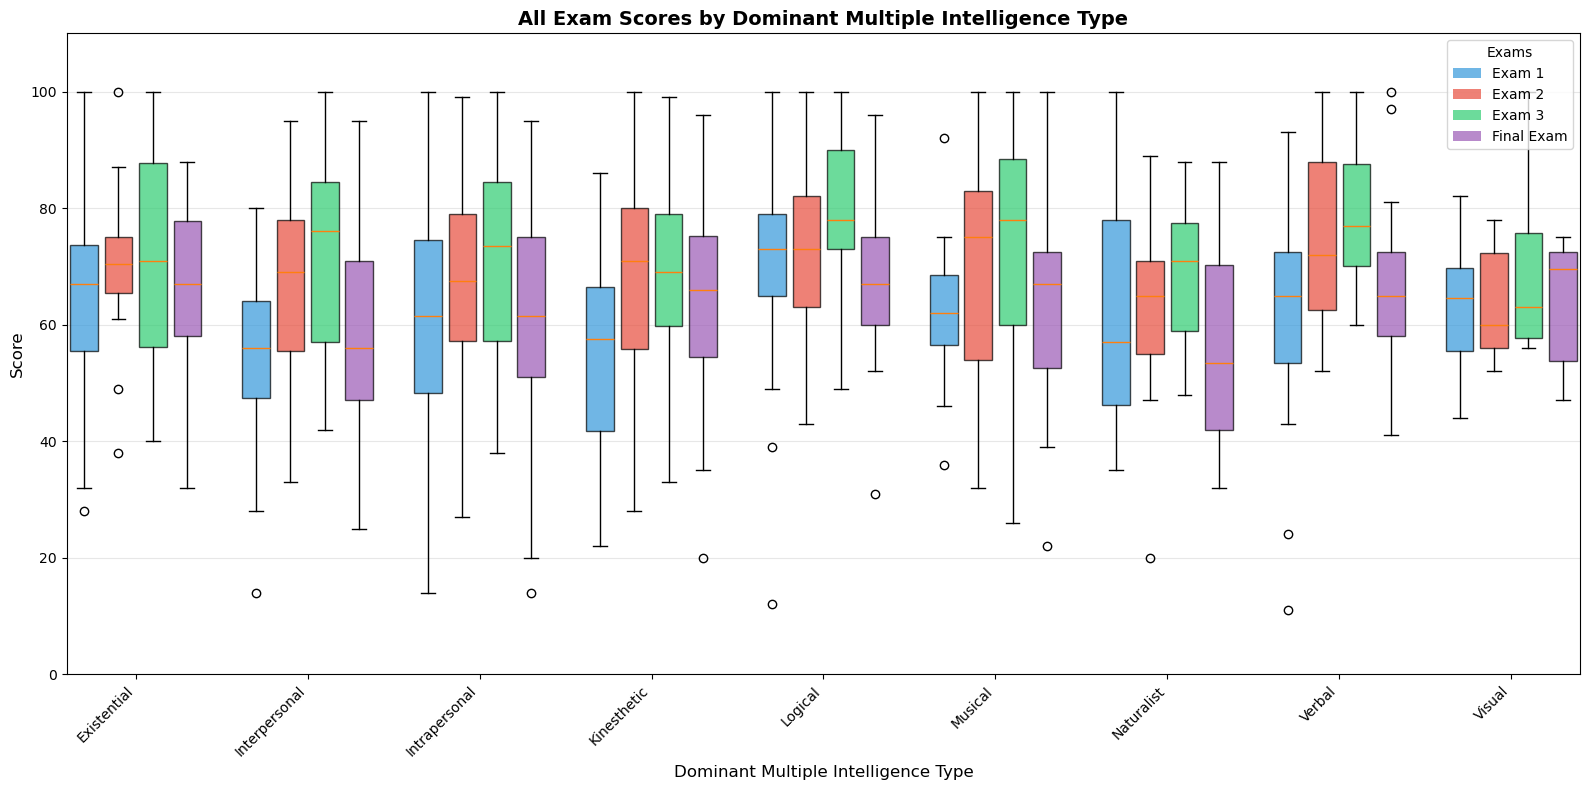

Plot 2 saved: mi_exam_boxplots_combined.png

Summary Statistics: Mean Exam Scores by Dominant MI Type
               Exam 1  Exam 2  Exam 3  Final Exam
Dominant_MI                                      
Existential     64.50   69.61   70.44       65.83
Interpersonal   55.09   67.49   72.20       58.71
Intrapersonal   60.54   66.98   72.40       61.22
Kinesthetic     54.00   67.67   68.96       63.96
Logical         69.00   72.24   78.14       67.43
Musical         62.15   69.59   73.56       63.74
Naturalist      63.57   63.07   69.07       56.14
Verbal          61.53   75.00   79.00       66.79
Visual          63.17   63.50   69.67       63.83


In [13]:
"""
Multiple Intelligence vs Exam Performance Boxplot Analysis
Using generated sample data similar to actual MI survey results
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of students
n_students = 214

# Generate MI scores (0-10 scale) for each student
mi_types = ['Naturalist', 'Musical', 'Logical', 'Existential', 
            'Interpersonal', 'Kinesthetic', 'Verbal', 'Intrapersonal', 'Visual']

# Create dataframe with MI scores
data = {'Students': range(1, n_students + 1)}

# Generate MI scores with different means to create varied dominant types
mi_means = {
    'Naturalist': 4.4,
    'Musical': 5.1,
    'Logical': 4.8,
    'Existential': 5.0,
    'Interpersonal': 5.2,
    'Kinesthetic': 5.3,
    'Verbal': 4.5,
    'Intrapersonal': 6.6,
    'Visual': 4.8
}

for mi in mi_types:
    scores = np.random.normal(mi_means[mi], 2, n_students)
    scores = np.clip(scores, 0, 10).round()  # Keep within 0-10 range
    data[mi] = scores

df = pd.DataFrame(data)

# Determine dominant MI type for each student
df['Dominant_MI'] = df[mi_types].idxmax(axis=1)

# Generate exam scores (0-100 scale) with some variation by MI type
# Logical and Verbal types tend to score slightly higher
exam_means = {'Exam 1': 60, 'Exam 2': 67, 'Exam 3': 73, 'Final Exam': 60}

for exam, base_mean in exam_means.items():
    scores = []
    for idx, row in df.iterrows():
        # Add slight bonus for Logical/Verbal dominant students
        bonus = 5 if row['Dominant_MI'] in ['Logical', 'Verbal'] else 0
        score = np.random.normal(base_mean + bonus, 18)
        score = np.clip(score, 0, 100).round()
        scores.append(score)
    df[exam] = scores

exam_cols = ['Exam 1', 'Exam 2', 'Exam 3', 'Final Exam']

# Print distribution of dominant MI types
print("Distribution of Dominant MI Types:")
print(df['Dominant_MI'].value_counts().sort_values(ascending=False))
print()

# ============================================================
# PLOT 1: Four separate boxplots (one per exam)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = plt.cm.Set3(np.linspace(0, 1, len(mi_types)))

for idx, exam in enumerate(exam_cols):
    ax = axes[idx]
    
    mi_list = sorted(df['Dominant_MI'].unique())
    data_list = [df[df['Dominant_MI'] == mi][exam].dropna().values for mi in mi_list]
    
    bp = ax.boxplot(data_list, tick_labels=mi_list, patch_artist=True)
    
    for patch, color in zip(bp['boxes'], colors[:len(mi_list)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'{exam} Scores by Dominant MI Type', fontsize=12, fontweight='bold')
    ax.set_xlabel('Dominant Multiple Intelligence Type', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 110)
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean markers
    means = [np.mean(d) for d in data_list]
    ax.scatter(range(1, len(mi_list) + 1), means, color='red', marker='D', 
               s=30, zorder=3, label='Mean')

plt.suptitle('Exam Performance by Dominant Multiple Intelligence Type', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mi_exam_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot 1 saved: mi_exam_boxplots.png")

# ============================================================
# PLOT 2: Combined boxplot (all exams grouped by MI type)
# ============================================================
fig, ax = plt.subplots(figsize=(16, 8))

mi_list = sorted(df['Dominant_MI'].unique())
positions = []
all_data = []
colors_list = []
exam_colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for i, mi in enumerate(mi_list):
    mi_data = df[df['Dominant_MI'] == mi]
    for j, exam in enumerate(exam_cols):
        all_data.append(mi_data[exam].dropna().values)
        positions.append(i * 5 + j)
        colors_list.append(exam_colors[j])

bp = ax.boxplot(all_data, positions=positions, patch_artist=True, widths=0.8)

for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks([i * 5 + 1.5 for i in range(len(mi_list))])
ax.set_xticklabels(mi_list, rotation=45, ha='right')
ax.set_xlabel('Dominant Multiple Intelligence Type', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Exam Scores by Dominant Multiple Intelligence Type', fontsize=14, fontweight='bold')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

legend_patches = [plt.Rectangle((0,0),1,1, facecolor=c, alpha=0.7) for c in exam_colors]
ax.legend(legend_patches, exam_cols, loc='upper right', title='Exams')

plt.tight_layout()
plt.savefig('mi_exam_boxplots_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot 2 saved: mi_exam_boxplots_combined.png")

# ============================================================
# Summary Statistics
# ============================================================
print("\n" + "="*60)
print("Summary Statistics: Mean Exam Scores by Dominant MI Type")
print("="*60)
summary = df.groupby('Dominant_MI')[exam_cols].mean().round(2)
print(summary.to_string())